# Explore the Data Structure

In this step, we will understand the dataset by examining its structure, columns, data types, summary statistics, missing values, and duplicate records.

In [2]:
import pandas as pd
import numpy as np

In [3]:
# Load the dataset
df = pd.read_csv("books.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
print("First Five Records:")
df.head()

First Five Records:


,Title,Price,Rating,Availability
0,A Light in the Attic,51.77,Three,In stock
1,Tipping the Velvet,53.74,One,In stock
2,Soumission,50.10,One,In stock
3,Sharp Objects,47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,54.23,Five,In stock


In [5]:
print("Last Five Records:")
df.tail()

Last Five Records:


,Title,Price,Rating,Availability
995,Alice in Wonderland (Alice's Adventures in Won...,55.53,One,In stock
996,"Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)",57.06,Four,In stock
997,A Spy's Devotion (The Regency Spies of London #1),16.97,Five,In stock
998,1st to Die (Women's Murder Club #1),53.98,One,In stock
999,"1,000 Places to See Before You Die",26.08,Five,In stock


In [6]:
print("Dataset Shape")
print("----------------")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Dataset Shape
----------------
Rows    : 1000
Columns : 4


In [7]:
print("Column Names")
print("-------------")

for column in df.columns:
    print(column)

Column Names
-------------
Title
Price
Rating
Availability


In [8]:
print("Data Types")
print("----------")

df.dtypes

Data Types
----------


Title               str
Price           float64
Rating              str
Availability        str
dtype: object

In [9]:
print("Statistical Summary")
print("-------------------")

df.describe(include="all")

Statistical Summary
-------------------


,Title,Price,Rating,Availability
count,1000,1000.00000,1000,1000
unique,999,NaN,5,1
top,The Star-Touched Queen,NaN,One,In stock
freq,2,NaN,226,1000
mean,NaN,35.07035,NaN,NaN
std,NaN,14.44669,NaN,NaN
min,NaN,10.00000,NaN,NaN
25%,NaN,22.10750,NaN,NaN
50%,NaN,35.98000,NaN,NaN
75%,NaN,47.45750,NaN,NaN


In [10]:
print("Missing Values")
print("--------------")

df.isnull().sum()

Missing Values
--------------


Title           0
Price           0
Rating          0
Availability    0
dtype: int64

In [11]:
print("Duplicate Records")
print("-----------------")

print(df.duplicated().sum())
print("Unique Values in Each Column")
print("----------------------------")

df.nunique()

Duplicate Records
-----------------
0
Unique Values in Each Column
----------------------------


Title           999
Price           903
Rating            5
Availability      1
dtype: int64

# Identify Trends, Patterns, and Anomalies

In this step, we analyze the dataset to identify trends, patterns, and unusual observations using statistical methods.

In [12]:
print("PRICE STATISTICS")
print("-" * 40)

print(f"Average Price : £{df['Price'].mean():.2f}")
print(f"Median Price  : £{df['Price'].median():.2f}")
print(f"Mode Price    : £{df['Price'].mode()[0]:.2f}")
print(f"Minimum Price : £{df['Price'].min():.2f}")
print(f"Maximum Price : £{df['Price'].max():.2f}")
print(f"Standard Deviation : £{df['Price'].std():.2f}")

PRICE STATISTICS
----------------------------------------
Average Price : £35.07
Median Price  : £35.98
Mode Price    : £16.28
Minimum Price : £10.00
Maximum Price : £59.99
Standard Deviation : £14.45


In [13]:
print("BOOK RATING DISTRIBUTION")
print("-" * 40)

print(df["Rating"].value_counts().sort_index())

BOOK RATING DISTRIBUTION
----------------------------------------
Rating
Five     196
Four     179
One      226
Three    203
Two      196
Name: count, dtype: int64


In [14]:
print("AVERAGE PRICE BY RATING")
print("-" * 40)

df.groupby("Rating")["Price"].mean().round(2)

AVERAGE PRICE BY RATING
----------------------------------------


Rating
Five     35.37
Four     36.09
One      34.56
Three    34.69
Two      34.81
Name: Price, dtype: float64

In [15]:
print("TOP 10 MOST EXPENSIVE BOOKS")
print("-" * 40)

df.nlargest(10, "Price")

TOP 10 MOST EXPENSIVE BOOKS
----------------------------------------


,Title,Price,Rating,Availability
648,The Perfect Play (Play by Play #1),59.99,Three,In stock
617,Last One Home (New Beginnings #1),59.98,Three,In stock
860,Civilization and Its Discontents,59.95,Two,In stock
560,The Barefoot Contessa Cookbook,59.92,Five,In stock
366,The Diary of a Young Girl,59.90,Three,In stock
657,The Bone Hunters (Lexy Vaughan & Steven Macaul...,59.71,Three,In stock
133,Thomas Jefferson and the Tripoli Pirates: The ...,59.64,One,In stock
387,Boar Island (Anna Pigeon #19),59.48,Three,In stock
393,The Improbability of Love,59.45,One,In stock
549,The Man Who Mistook His Wife for a Hat and Oth...,59.45,Four,In stock


In [16]:
print("TOP 10 CHEAPEST BOOKS")
print("-" * 40)

df.nsmallest(10, "Price")

TOP 10 CHEAPEST BOOKS
----------------------------------------


,Title,Price,Rating,Availability
638,An Abundance of Katherines,10.00,Five,In stock
501,The Origin of Species,10.01,Four,In stock
716,The Tipping Point: How Little Things Can Make ...,10.02,Two,In stock
84,Patience,10.16,Three,In stock
302,Greek Mythic History,10.23,Five,In stock
558,The Fellowship of the Ring (The Lord of the Ri...,10.27,Two,In stock
479,History of Beauty,10.29,Four,In stock
242,The Lucifer Effect: Understanding How Good Peo...,10.40,One,In stock
434,"NaNo What Now? Finding your editing process, r...",10.41,Four,In stock
274,Pet Sematary,10.56,Three,In stock


In [17]:
print("PRICE QUARTILES")
print("-" * 40)

print(df["Price"].quantile([0.25, 0.50, 0.75]))

PRICE QUARTILES
----------------------------------------
0.25    22.1075
0.50    35.9800
0.75    47.4575
Name: Price, dtype: float64


In [18]:
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df["Price"] < lower_limit) | (df["Price"] > upper_limit)]

print("OUTLIER ANALYSIS")
print("-" * 40)
print(f"Number of Outliers : {len(outliers)}")
print("OUTLIER RECORDS")
print("-" * 40)

outliers

OUTLIER ANALYSIS
----------------------------------------
Number of Outliers : 0
OUTLIER RECORDS
----------------------------------------


,Title,Price,Rating,Availability


In [19]:
price_bins = [0,10,20,30,40,50,60]

price_labels = [
    "£0-10",
    "£10-20",
    "£20-30",
    "£30-40",
    "£40-50",
    "£50-60"
]

df["Price Range"] = pd.cut(
    df["Price"],
    bins=price_bins,
    labels=price_labels
)

print("PRICE RANGE DISTRIBUTION")
print("-" * 40)

df["Price Range"].value_counts().sort_index()


PRICE RANGE DISTRIBUTION
----------------------------------------


Price Range
£0-10       1
£10-20    195
£20-30    207
£30-40    194
£40-50    205
£50-60    198
Name: count, dtype: int64

In [20]:
print("MOST COMMON PRICE RANGE")
print("-" * 40)

print(df["Price Range"].value_counts().idxmax())

MOST COMMON PRICE RANGE
----------------------------------------
£20-30


# Test Hypotheses and Validate Assumptions

In this step, we test assumptions about the dataset using statistical analysis to determine whether the hypotheses are supported by the data.

In [21]:
print("Hypothesis 1")
print("-" * 50)

average_price = df.groupby("Rating")["Price"].mean().round(2)

print("Average Price by Rating:")
print(average_price)

Hypothesis 1
--------------------------------------------------
Average Price by Rating:
Rating
Five     35.37
Four     36.09
One      34.56
Three    34.69
Two      34.81
Name: Price, dtype: float64


The average prices across different ratings are very similar, ranging from approximately £34.56 to £36.09. Although four-star books have the highest average price, there is no consistent increase in price with higher ratings. Therefore, the hypothesis is **not strongly supported**.

In [22]:
print("Hypothesis 2")
print("-" * 50)

print(df["Price Range"].value_counts().sort_index())

Hypothesis 2
--------------------------------------------------
Price Range
£0-10       1
£10-20    195
£20-30    207
£30-40    194
£40-50    205
£50-60    198
Name: count, dtype: int64


The majority of books are distributed across the price ranges of £20–30, £40–50, and £50–60, with each range containing nearly 200 books. This indicates that the dataset has a fairly balanced price distribution rather than being concentrated in a single middle price range. Therefore, the hypothesis is **not strongly supported**.

In [23]:
print("Hypothesis 3")
print("-" * 50)

print(f"Number of Outliers: {len(outliers)}")
print(f"Percentage of Outliers: {(len(outliers)/len(df))*100:.2f}%")

Hypothesis 3
--------------------------------------------------
Number of Outliers: 0
Percentage of Outliers: 0.00%


No outliers were detected using the Interquartile Range (IQR) method. This indicates that the book prices are well distributed without any extreme values. Therefore, the hypothesis is **supported**.

In [24]:
print("Hypothesis 4")
print("-" * 50)

rating_counts = df["Rating"].value_counts().sort_index()

print(rating_counts)

Hypothesis 4
--------------------------------------------------
Rating
Five     196
Four     179
One      226
Three    203
Two      196
Name: count, dtype: int64


The ratings are not evenly distributed across the dataset. One-star books are the most common (226 books), while four-star books are the least common (179 books). Therefore, the hypothesis is **supported**.

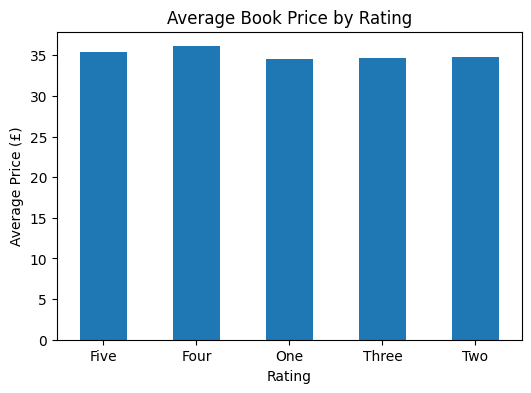

In [25]:
import matplotlib.pyplot as plt

avg_price = df.groupby("Rating")["Price"].mean()

plt.figure(figsize=(6,4))
avg_price.plot(kind="bar")
plt.title("Average Book Price by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Price (£)")
plt.xticks(rotation=0)
plt.show()

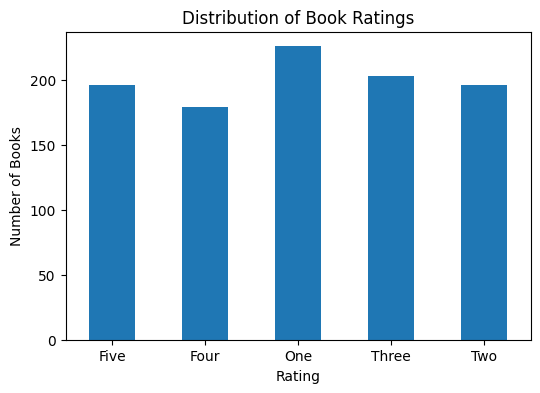

In [26]:
rating_counts = df["Rating"].value_counts().sort_index()

plt.figure(figsize=(6,4))
rating_counts.plot(kind="bar")
plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.xticks(rotation=0)
plt.show()

# Detect Potential Data Issues

In this step, we examine the dataset for data quality issues such as missing values, duplicate records, incorrect data types, invalid values, and outliers. Ensuring good data quality is important before performing further analysis or building machine learning models.

In [27]:
print("MISSING VALUES")
print("-" * 50)

missing_values = df.isnull().sum()

print(missing_values)

MISSING VALUES
--------------------------------------------------
Title           0
Price           0
Rating          0
Availability    0
Price Range     0
dtype: int64


In [28]:
print("DUPLICATE RECORDS")
print("-" * 50)

duplicates = df.duplicated().sum()

print(f"Number of Duplicate Records: {duplicates}")

DUPLICATE RECORDS
--------------------------------------------------
Number of Duplicate Records: 0


In [29]:
print("DATA TYPES")
print("-" * 50)

print(df.dtypes)

DATA TYPES
--------------------------------------------------
Title                str
Price            float64
Rating               str
Availability         str
Price Range     category
dtype: object


In [30]:
print("INVALID PRICE VALUES")
print("-" * 50)

negative_prices = df[df["Price"] < 0]

print(f"Negative Price Records: {len(negative_prices)}")

INVALID PRICE VALUES
--------------------------------------------------
Negative Price Records: 0


In [31]:
print("RATING CATEGORIES")
print("-" * 50)

print(df["Rating"].unique())

RATING CATEGORIES
--------------------------------------------------
<ArrowStringArray>
['Three', 'One', 'Four', 'Five', 'Two']
Length: 5, dtype: str


In [32]:
print("OUTLIER SUMMARY")
print("-" * 50)

print(f"Number of Outliers: {len(outliers)}")

OUTLIER SUMMARY
--------------------------------------------------
Number of Outliers: 0
